In [40]:
import os
import pandas as pd
import numpy as np
from functions import *
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st # for Cumulative Distribution Function in VdW score 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Load the data (download pre_processing.csv from ".....")

In [41]:
df = pd.read_parquet('datasets/pre_processing.parquet')

Keep data with listings over 11 years

In [42]:
# count number of years per id
obs_per_id = df.groupby(['mun_istat'])['year'].nunique()

# count how many ids have 1 year, 2 years, etc.
count_by_years = obs_per_id.value_counts().sort_index()

print(count_by_years)

year
1        2
2        1
3       21
4        5
5        1
7       38
8        7
9        6
10      21
11    7771
Name: count, dtype: int64


In [43]:
# keep only ids with listings over 11 years - balanced panel data
ids_eleven = obs_per_id[obs_per_id == 11].index

# filter the data
df = df[df['mun_istat'].isin(ids_eleven)]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85481 entries, 0 to 86158
Data columns (total 57 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   mun_istat                 85481 non-null  object  
 1   year                      85481 non-null  int64   
 2   mun_name                  85481 non-null  object  
 3   mun_name_norm             85481 non-null  object  
 4   location                  85481 non-null  category
 5   region                    85481 non-null  object  
 6   prov                      85481 non-null  object  
 7   buy_min                   85481 non-null  float64 
 8   buy_max                   85481 non-null  float64 
 9   prov_istat                85481 non-null  object  
 10  population                85481 non-null  float64 
 11  surface                   85481 non-null  float64 
 12  median_income             85481 non-null  float64 
 13  changed                   85481 non-null  bool    


Cumulative data per province (population, dwellings, tourism values)

In [44]:
sum_col = [
    'population', 
    'dwellings', 
    'surface', 
    'five_stars_beds',
    'four_stars_beds',
    'three_stars_beds',
    'two_stars_beds',
    'one_stars_beds',
    'holiday_dwelling_count',
    'holiday_dwelling_beds',
    "tourism_residence_beds",
    "camp_sites_beds",
    "farmhouses_beds",
    "hostels_beds",
    "tourist_dormitories_beds",
    "mountain_huts_beds",
    "bnb_beds",
    'tot_count',
    'tot_acc_beds',
    'tot_beds',
    'tot_arrivals_residents',
    'tot_arrivals_foreigners',
    'tot_arrivals',
    'tot_nights_residents',
    'tot_nights_foreigners',
    'tot_nights']

for col in sum_col:
    df['prov_' + col] = df.groupby(['year', 'prov'], observed=True)[col].transform('sum')

Weighted averages per province (buy_min, buy_max, median_income)

In [45]:
# buy_min * dwellings
df['buy_min_fraction'] = (df['buy_min'] * df['dwellings']) / df['prov_dwellings']
df['prov_buy_min_wgt'] = df.groupby(['year','prov'], observed=True)['buy_min_fraction'].transform('sum')

# buy_max * dwellings
df['buy_max_fraction'] = (df['buy_max'] * df['dwellings']) / df['prov_dwellings']
df['prov_buy_max_wgt'] = df.groupby(['year','prov'], observed=True)['buy_max_fraction'].transform('sum')

# median_income * population
df['median_income_fraction'] = (df['median_income'] * df['population']) / df['prov_population']
df['prov_median_income_wgt'] = df.groupby(['year','prov'], observed=True)['median_income_fraction'].transform('sum')

# drop fraction cols
df = df.drop(columns = ['buy_min_fraction', 'buy_max_fraction', 'median_income_fraction'])

Deflate prices (already deflated) - test correlation

In [46]:
df["price_growth"] = df.groupby("prov")["prov_buy_min_wgt"].pct_change()
df["cpi_growth"] = df["cpi_index"].pct_change()

df[["price_growth", "cpi_growth"]].corr()

,price_growth,cpi_growth
price_growth,1.000000,-0.471601
cpi_growth,-0.471601,1.000000


Immigration and emigration ratios

In [47]:
# total number of immigrants and emigrants (standardized per 100 inhabitants) - SEMI-ELASTICITY
df['prov_immigration'] = ((df['abroad_in'] + df['nation_in']) / df['population']) * 100

df['prov_emigration'] = ((df['abroad_out'] + df['nation_out']) / df['population']) * 100

Tourism indexes

In [48]:
# total number of hotel beds
hotel_col = [
    'prov_five_stars_beds',
    'prov_four_stars_beds',
    'prov_three_stars_beds',
    'prov_two_stars_beds',
    'prov_one_stars_beds'
]

df['prov_hotel_beds'] = df[hotel_col].sum(axis = 1).astype(int)

# drop hotel_col
df = df.drop(columns = hotel_col)

# HOTEL PRESSURE ON MUNICIPALITY - ratio between hotel beds and population (per 100 inhabitants) 
df['prov_ratio_hotel_beds'] = (df['prov_hotel_beds'] / df['prov_population']) * 100

#################################

# STR PRESSURE ON MUNICIPALITY (1)  - ratio of holiday dwellings and population (per 100 dwellings) 
df['prov_ratio_str_houses'] = (df['prov_holiday_dwelling_count'] / df['prov_dwellings']) * 100

# STR PRESSURE ON MUNICIPALITY (2)  - ratio of holiday beds and population (per 100 inhabitants) 
df['prov_ratio_str_beds'] = (df['prov_holiday_dwelling_beds'] / df['prov_population']) * 100

#################################

# OTHER ACCOMODATIONS PRESSURE ON MUNICIPALITY - ratio between other accommodation beds and population (per 100 inhabitants) 
df['prov_other_acc_beds'] = ((df['prov_tot_beds'] - df['prov_hotel_beds'] - df['prov_holiday_dwelling_beds']) / df['prov_population']) * 100

#################################

# measure the ratio between arrivals and population (per 100 inhabitants) 
df['prov_ratio_arrivals_residents'] = (df['prov_tot_arrivals_residents'] / df['prov_population']) * 100

# measure the ratio between foreigner arrivals and population (per 100 inhabitants) 
df['prov_ratio_arrivals_foreigners'] = (df['prov_tot_arrivals_foreigners'] / df['prov_population']) * 100

# measure the ratio between total arrivals and population (per 100 inhabitants) 
df['prov_ratio_tot_arrivals'] = (df['prov_tot_arrivals'] / df['prov_population']) * 100

#################################

# measure the ratio between residents nights and population (per 100 inhabitants)
df['prov_ratio_tot_nights_residents'] = (df['prov_tot_nights_residents'] / df['prov_population']) * 100

# measure the ratio between foreigner nights and population (per 100 inhabitants)
df['prov_ratio_tot_nights_foreigners'] = (df['prov_tot_nights_foreigners'] / df['prov_population']) * 100

# measure the ratio between total nights and population (per 100 inhabitants)
df['prov_ratio_tot_nights'] = (df['prov_tot_nights'] / df['prov_population']) * 100

#################################

# measure the ratio between total beds and population (per 100 inhabitants) - FOR INDEX BRAKE DOWN
df['prov_ratio_tot_beds'] = (df['prov_tot_beds'] / df['prov_population']) * 100

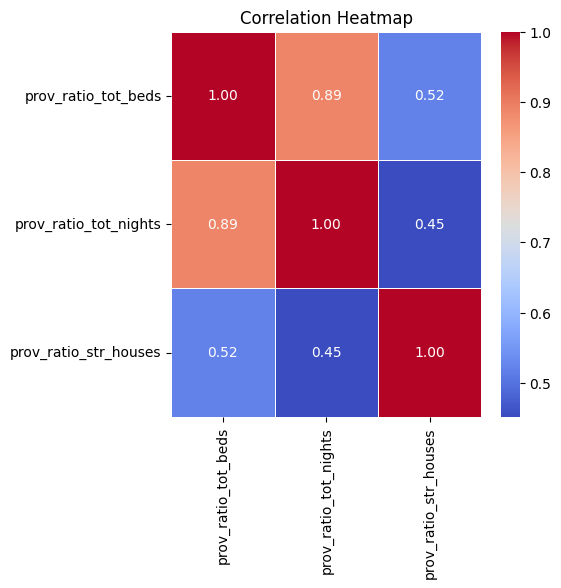

In [49]:
# correlation matrix
var_corr = [
    'prov_ratio_tot_beds',
    'prov_ratio_tot_nights',
    'prov_ratio_str_houses'
]

matrix = df[var_corr].corr()

plt.figure(figsize=(5,5))
sns.heatmap(matrix, annot = True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [50]:
# compute Van der Waerden score as a tourist index - consider prov_ratios
# define the function
def van_der_waerden_score(x):
    # create a rank
    ranks = x.rank(method='average')
    n = len(x)
    # define the score between 0 and 100
    score = (ranks / (n + 1)) * 100
    return score


vars_tourism = [
    'prov_ratio_tot_beds',
    'prov_ratio_tot_nights',
    'prov_ratio_str_houses'
]

df['tourism_index_rnk'] = (
    df
    .groupby('year')[vars_tourism]
    .transform(lambda x: van_der_waerden_score(x))
    .mean(axis=1)
)

# check minimum and maximum tourism score
print("Minimum tourism score: ", df['tourism_index_rnk'].min())
print("Maximum tourism score: ", df['tourism_index_rnk'].max())

Minimum tourism score:  1.173014239149082
Maximum tourism score:  99.00283067421513


In [51]:
# compute z-score as a tourist index - consider ratio variables in prov cities
def z_score(x):
    return 100 * (x - x.min()) / (x.max() - x.min())

vars_tourism = [
    'prov_ratio_tot_beds',
    'prov_ratio_tot_nights',
    'prov_ratio_str_houses'
]

df['tourism_index_z'] = (
    df
    .groupby('year')[vars_tourism]
    .transform(z_score)
    .mean(axis=1)
)

In [52]:
print("Minimum z-score tourism index:", df['tourism_index_z'].min())
print("Maximum z-score tourism index:", df['tourism_index_z'].max())
print("Mean:", df['tourism_index_z'].mean())
print("Std:", df['tourism_index_z'].std())

Minimum z-score tourism index: 0.05490159162387612
Maximum z-score tourism index: 89.14955023855696
Mean: 10.548813959476602
Std: 14.051218084346809


Group by province

In [53]:
df_prov = df.groupby(['year','prov'], observed=True).agg({
    'location':'first',
    'region':'first',
    'prov_buy_min_wgt':'first',
    'prov_buy_max_wgt':'first',
    'prov_median_income_wgt':'first',
    'prov_population':'first',
    'prov_surface' : 'first',
    'prov_dwellings':'first',
    'prov_immigration':'first',
    'prov_emigration':'first',
    'prov_unemployment':'first',
    'over65':'first',
    'reg_age_avg':'first',
    'prov_ratio_hotel_beds':'first',
    'prov_ratio_str_beds':'first',
    'prov_ratio_str_houses':'first',
    'prov_other_acc_beds' : 'first',
    'prov_ratio_arrivals_residents':'first',
    'prov_ratio_arrivals_foreigners':'first',
    'prov_ratio_tot_arrivals' : 'first',
    'prov_ratio_tot_nights_residents':'first',
    'prov_ratio_tot_nights_foreigners':'first',
    'prov_ratio_tot_nights' : 'first',
    'prov_ratio_tot_beds' : 'first',
    'tourism_index_rnk':'first',
    'tourism_index_z':'first',
    'tour_employed':'first',
    'real_gdp':'first',
    'nominal_gdp':'first',
    'cpi_index' : 'first',
    'life':'first',
    'interest_rate':'first'
}).reset_index()

Log transform

In [54]:
log_col = ['prov_buy_min_wgt',
           'prov_buy_max_wgt',
           'prov_population',
           'prov_dwellings',
           'prov_surface',
           'prov_median_income_wgt',
           'prov_immigration',
           'prov_emigration',
           'tourism_index_rnk',
           'tourism_index_z',
           'real_gdp',
           'nominal_gdp',
           'tour_employed',
           'reg_age_avg',
           'over65',
           'life',
           'prov_unemployment',
           'interest_rate',
           'cpi_index',
           'prov_ratio_hotel_beds',
           'prov_ratio_str_houses',
           'prov_ratio_str_beds',
           'prov_other_acc_beds',
           'prov_ratio_arrivals_residents',
           'prov_ratio_arrivals_foreigners',
           'prov_ratio_tot_arrivals',
           'prov_ratio_tot_nights_residents',
           'prov_ratio_tot_nights_foreigners',
           'prov_ratio_tot_nights',
           'prov_ratio_tot_beds']

for col in log_col:
    df_prov['log_' + col] = np.log(df_prov[col] + 1e-6)  # add a small constant to avoid log(0)

Growth rates

In [55]:
diff_col = ['log_prov_buy_min_wgt',
           'log_prov_buy_max_wgt',
           'log_prov_population',
           'log_prov_dwellings',
           'log_prov_surface',
           'log_prov_median_income_wgt',
           'log_prov_immigration',
           'log_prov_emigration',
           'log_tourism_index_rnk',
           'log_tourism_index_z',
           'log_real_gdp',
           'log_nominal_gdp',
           'log_tour_employed',
           'log_reg_age_avg',
           'log_over65',
           'log_life',
           'log_prov_unemployment',
           'log_interest_rate',
           'log_cpi_index',
           'log_prov_ratio_hotel_beds',
           'log_prov_ratio_str_houses',
           'log_prov_ratio_str_beds',
           'log_prov_other_acc_beds',
           'log_prov_ratio_arrivals_residents',
           'log_prov_ratio_arrivals_foreigners',
           'log_prov_ratio_tot_arrivals',
           'log_prov_ratio_tot_nights_residents',
           'log_prov_ratio_tot_nights_foreigners',
           'log_prov_ratio_tot_nights',
           'log_prov_ratio_tot_beds']

for col in diff_col:
    df_prov['d_' + col] = df_prov.groupby('prov')[col].diff()

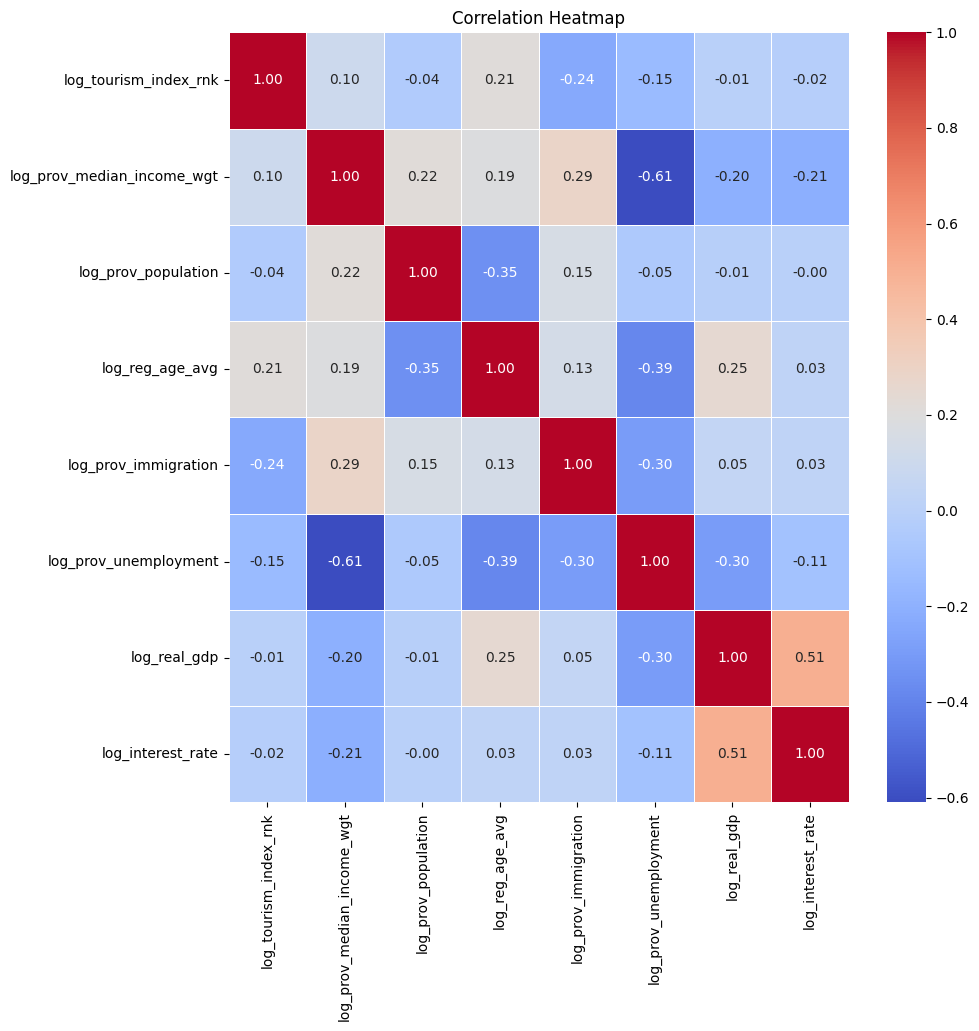

In [56]:
# correlation matrix
var_corr = [
    'log_tourism_index_rnk',
    'log_prov_median_income_wgt',
    'log_prov_population',
    'log_reg_age_avg',
    'log_prov_immigration',
    'log_prov_unemployment',
    'log_real_gdp',
    'log_interest_rate'
]

matrix = df_prov[var_corr].corr()

plt.figure(figsize=(10,10))
sns.heatmap(matrix, annot = True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Save

In [57]:
df_prov.to_csv('datasets/model.csv', index = False)

Visualise

In [65]:
df_prov[[
    'prov_buy_min_wgt',
    'prov_buy_max_wgt',
    'tourism_index_rnk',
    'tourism_index_z',
    'prov_population',
    'reg_age_avg',
    'prov_immigration',
    'prov_median_income_wgt',
    'prov_unemployment',
    'real_gdp',
    'interest_rate'
]].describe()

,prov_buy_min_wgt,prov_buy_max_wgt,tourism_index_rnk,tourism_index_z,prov_population,reg_age_avg,prov_immigration,prov_median_income_wgt,prov_unemployment,real_gdp,interest_rate
count,1210.000000,1210.000000,1210.000000,1210.000000,1.210000e+03,1210.000000,1210.000000,1210.000000,1210.000000,1.210000e+03,1210.000000
mean,1087.955065,1469.438026,54.179606,12.193410,5.383175e+05,45.770521,472.830863,15576.901971,10.383388,1.616458e+06,2.384798
std,445.899247,596.106876,26.820234,15.026784,5.943572e+05,2.083010,849.737950,2729.064011,5.690805,6.912378e+04,0.869693
min,430.069936,609.116593,1.173014,0.054902,5.165400e+04,40.169304,3.942133,9294.967415,1.600000,1.483850e+06,1.320925
25%,746.261368,1035.329072,31.086486,2.774818,2.259792e+05,44.474184,69.928674,13189.646580,6.200000,1.563290e+06,1.691567
50%,1021.698371,1326.087696,56.527706,6.938369,3.688475e+05,45.665030,175.312492,15826.184240,8.700000,1.616373e+06,2.139983
75%,1308.156572,1729.387501,77.368009,14.906672,5.869380e+05,46.878978,476.007391,17984.088327,13.600000,1.694301e+06,3.185883
max,2726.387063,3539.712118,99.002831,89.149550,4.141267e+06,61.968029,7095.597484,21384.856438,31.500000,1.722683e+06,4.164800


Text(0, 0.5, 'Z-score Tourism Index')

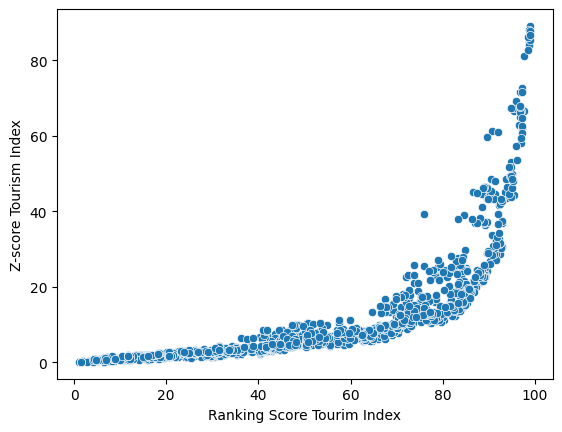

In [59]:
sns.scatterplot(data=df_prov, x='tourism_index_rnk', y='tourism_index_z')
plt.xlabel('Ranking Score Tourim Index')
plt.ylabel('Z-score Tourism Index')

In [62]:
df_prov['rank_vdw'] = df_prov.groupby('year')['tourism_index_rnk'].rank()
df_prov['rank_z'] = df_prov.groupby('year')['tourism_index_z'].rank()

df_prov[['rank_vdw', 'rank_z']].corr()

,rank_vdw,rank_z
rank_vdw,1.000000,0.975558
rank_z,0.975558,1.000000


In [63]:
df_2024 = df_prov[df_prov['year'] == 2024]

ranking_2024 = (
    df_2024
    .sort_values(by='tourism_index_rnk', ascending=False)
    .reset_index(drop=True)
)

ranking_2024[['prov', 'year', 'tourism_index_rnk']]


ranking_2024 = (
    df_2024
    .sort_values(by='tourism_index_z', ascending=False)
    .reset_index(drop=True)
)

ranking_2024[['prov', 'year', 'tourism_index_z']]

,prov,year,tourism_index_z
0,VE,2024,86.829561
1,BZ,2024,71.602115
2,RN,2024,57.334541
3,OT,2024,51.805187
4,GR,2024,48.629386
...,...,...,...
105,AV,2024,0.797287
106,CR,2024,0.758402
107,CL,2024,0.612100
108,MB,2024,0.494053
